<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/ML_(KMEANS)_clustering%26HIERARCHIAL_CLUSTERING_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [ ]:
# Load the dataset
df=pd.read_csv("/content/Mall_Customers.csv")

# Display first 5 rows
print(df.head())

# Select features for clustering (Annual Income & Spending Score)
x=df.iloc[:, [3,4]].values

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:

# -----------------------
# Step 1: Elbow Method to determine optimal K
# -----------------------

inertia=[]
k_values=range(1,11)

for k in k_values:
  kmeans = KMeans(n_clusters=k, init="k-means++",random_state=42)
  kmeans.fit(x)
  inertia.append(kmeans.inertia_)

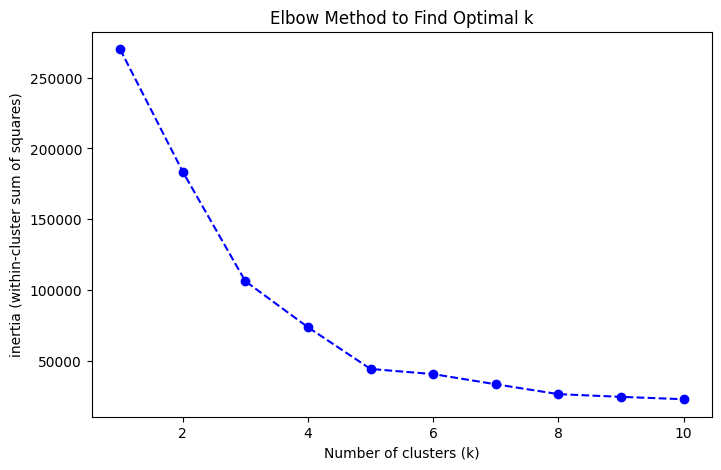

In [ ]:
# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia,marker="o",linestyle="--",color="blue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("inertia (within-cluster sum of squares)")
plt.title("Elbow Method to Find Optimal k")
plt.show()

In [ ]:
# -----------------------
# Step 2: Apply K-Means Clustering with Optimal K
# -----------------------
optimal_k = 5  # From elbow method
kmeans=KMeans(n_clusters=optimal_k, init="k-means++",random_state=42)
y_kmeans=kmeans.fit_predict(x) # Assign clusters to data points


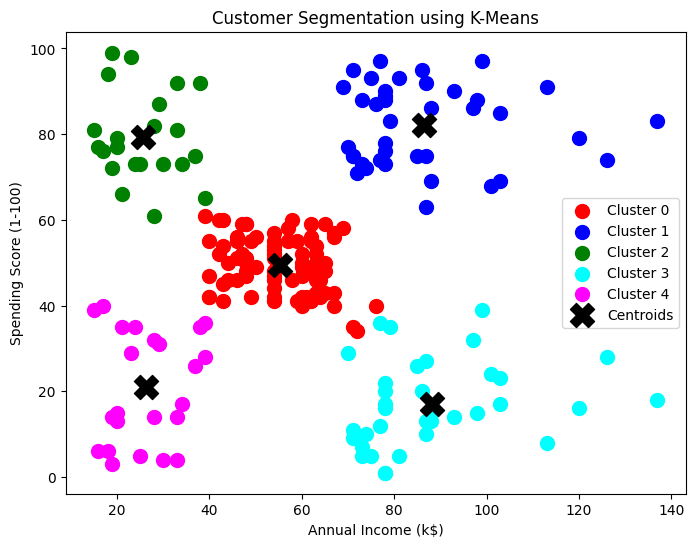

In [ ]:
# -----------------------
# Step 3: Visualizing Clusters
# -----------------------
plt.figure(figsize=(8,6))
colors = ["red", "blue", "green", "cyan", "magenta"]
for i in range(optimal_k):
    plt.scatter(x[y_kmeans == i, 0], x[y_kmeans == i, 1],
                s=100, color=colors[i], label=f"Cluster {i}")

# Plot Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, color="k", marker="X", label="Centroids")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Define a new data point
new_data = np.array([[15, 39]])

# Predict the cluster for the new data point
predicted_cluster = kmeans.predict(new_data)

print(f"The new data point {new_data[0]} belongs to Cluster {predicted_cluster[0]}")

The new data point [15 39] belongs to Cluster 4


# **HIERARCHIAL CLUSTERING**

- Start with every data point as its own group
- Then merge the closest groups again and again
- Keep doing this until everything becomes one big group

This creates a tree-like structure called a dendrogram.

Two Types

- Agglomerative (most common)
 - Start with many small clusters
 - Keep merging them
 - Bottom → Top approach
- Divisive
 - Start with one big cluster
 - Keep splitting it
 - Top → Bottom approach

Real-life Example

Think of grouping students:

First: best friends form small groups
Then: groups combine based on similarity
Finally: whole class becomes one group

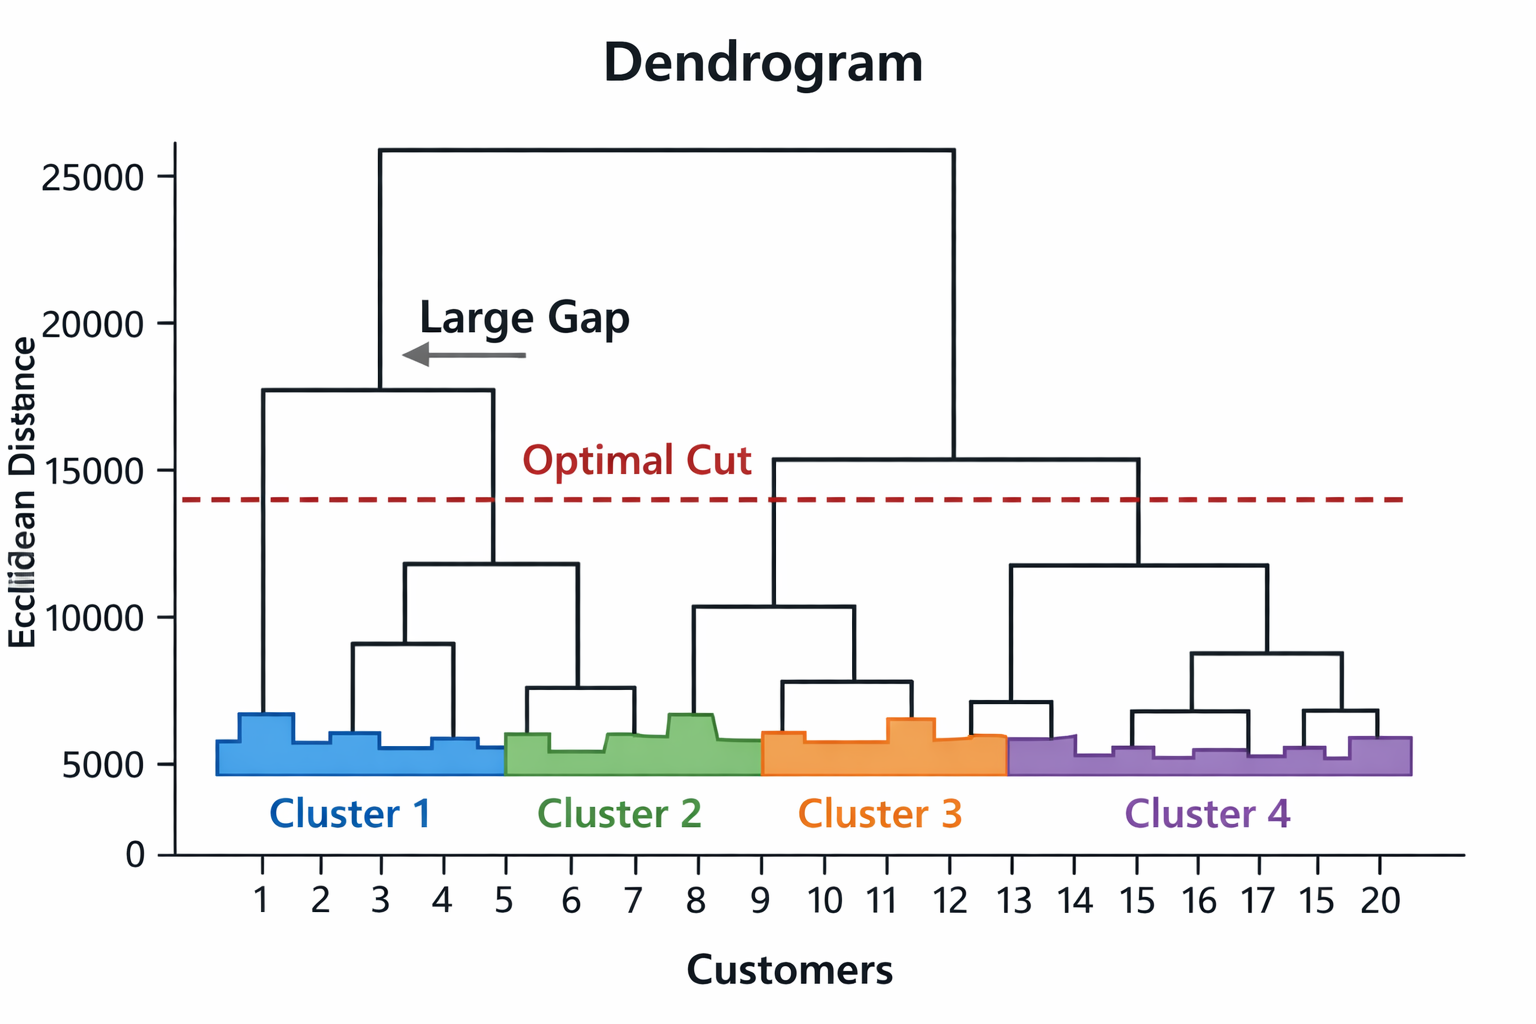


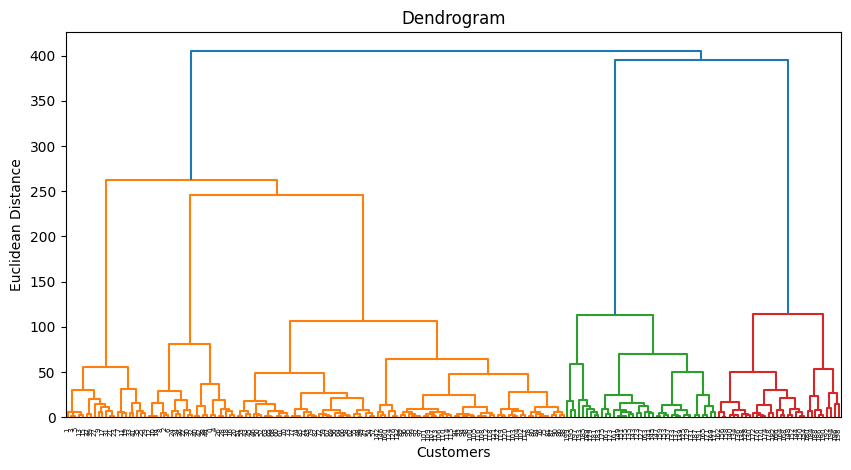

In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
y_hc = hc.fit_predict(x)

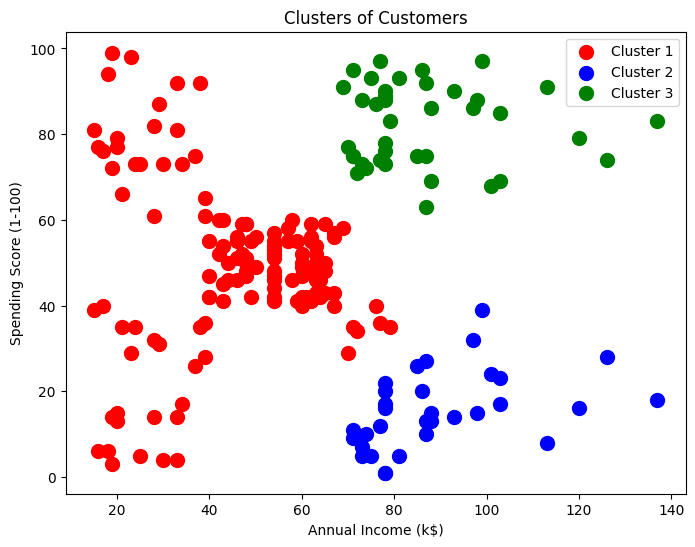

In [ ]:
import matplotlib.pyplot as plt

# Define colors for clusters
colors = ["red", "blue", "green", "cyan", "magenta"]

# Plot clusters dynamically
plt.figure(figsize=(8, 6))
for i in range(3):  # Number of unique clusters
    plt.scatter(x[y_hc == i, 0], x[y_hc == i, 1],
                s=100, color=colors[i], label=f"Cluster {i+1}")

# Add titles and labels
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


+1 → Perfect clustering (very well separated)
0 → Clusters overlap
-1 → Wrong clustering (points assigned to wrong clusters)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_hc)
print(f"Silhouette Score: {score:.3f}")